In [1]:
import pandas as pd
import numpy as np
import os
import torch
import matplotlib.pyplot as plt
import datetime
import sys
import pickle

import seaborn as sns


import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader

from scipy.stats import beta

from sklearn import linear_model
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import roc_auc_score, confusion_matrix

import matplotlib.pyplot as pltP
import subprocess

from utils_for_analysis import (
    calculate_ss_for_df_and_factors,
    load_df_all,
    discretized_parameter_scale,
    xlabel_dict,
    ylabel_dict,
    title_fontsize,
    label_fontsize,
    tick_fontsize,
    legend_fontsize,
    load_df_with_budget
)

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..', 'code')))
from example_run_jobs import *

plt.rcParams['svg.fonttype'] = 'none'


In [2]:
df_gfp = pd.read_csv("data/gfp/gfp_dataset_10mut.csv")
df_nmt = pd.read_csv("data/nmt/nmt_full_seq.csv")

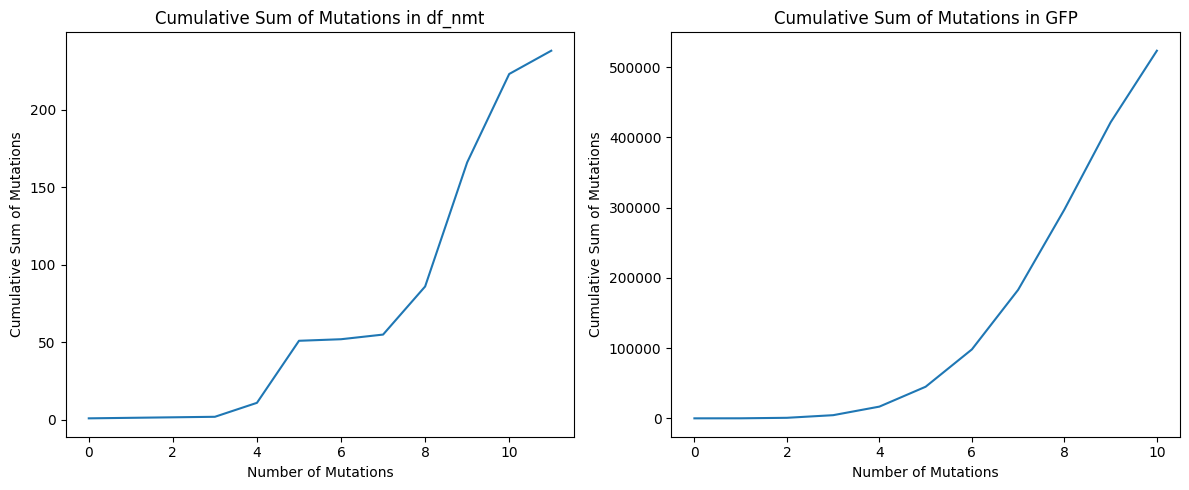

In [3]:
nmuts_nmt =  df_nmt["num_muts"]
nmuts_gfp =  df_gfp["num_muts"]

counts_nmt = np.unique(nmuts_nmt, return_counts=True)
counts_gfp = np.unique(nmuts_gfp, return_counts=True)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].plot(counts_nmt[0], counts_nmt[1].cumsum())
axs[0].set_xlabel("Number of Mutations")
axs[0].set_ylabel("Cumulative Sum of Mutations")
axs[0].set_title("Cumulative Sum of Mutations in df_nmt")

axs[1].plot(counts_gfp[0], counts_gfp[1].cumsum())
axs[1].set_xlabel("Number of Mutations")
axs[1].set_ylabel("Cumulative Sum of Mutations")
axs[1].set_title("Cumulative Sum of Mutations in GFP")

plt.tight_layout()
plt.show()

In [4]:


# Directory where the files are stored
base_path = "/home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks/data"
nmt_base_path = "%s/nmt/results/by_complexity_and_budget_up_to_11/" % base_path
gcn_base_path = "%s/gcn4/results/by_complexity_and_budget_up_to_8/" % base_path




nmt_sets = load_df_with_budget(nmt_base_path)
gcn_sets = load_df_with_budget(gcn_base_path)

#df.head()

In [5]:
nmt_sets.keys()

dict_keys(['held_out_9', 'held_out_10', 'held_out_11'])

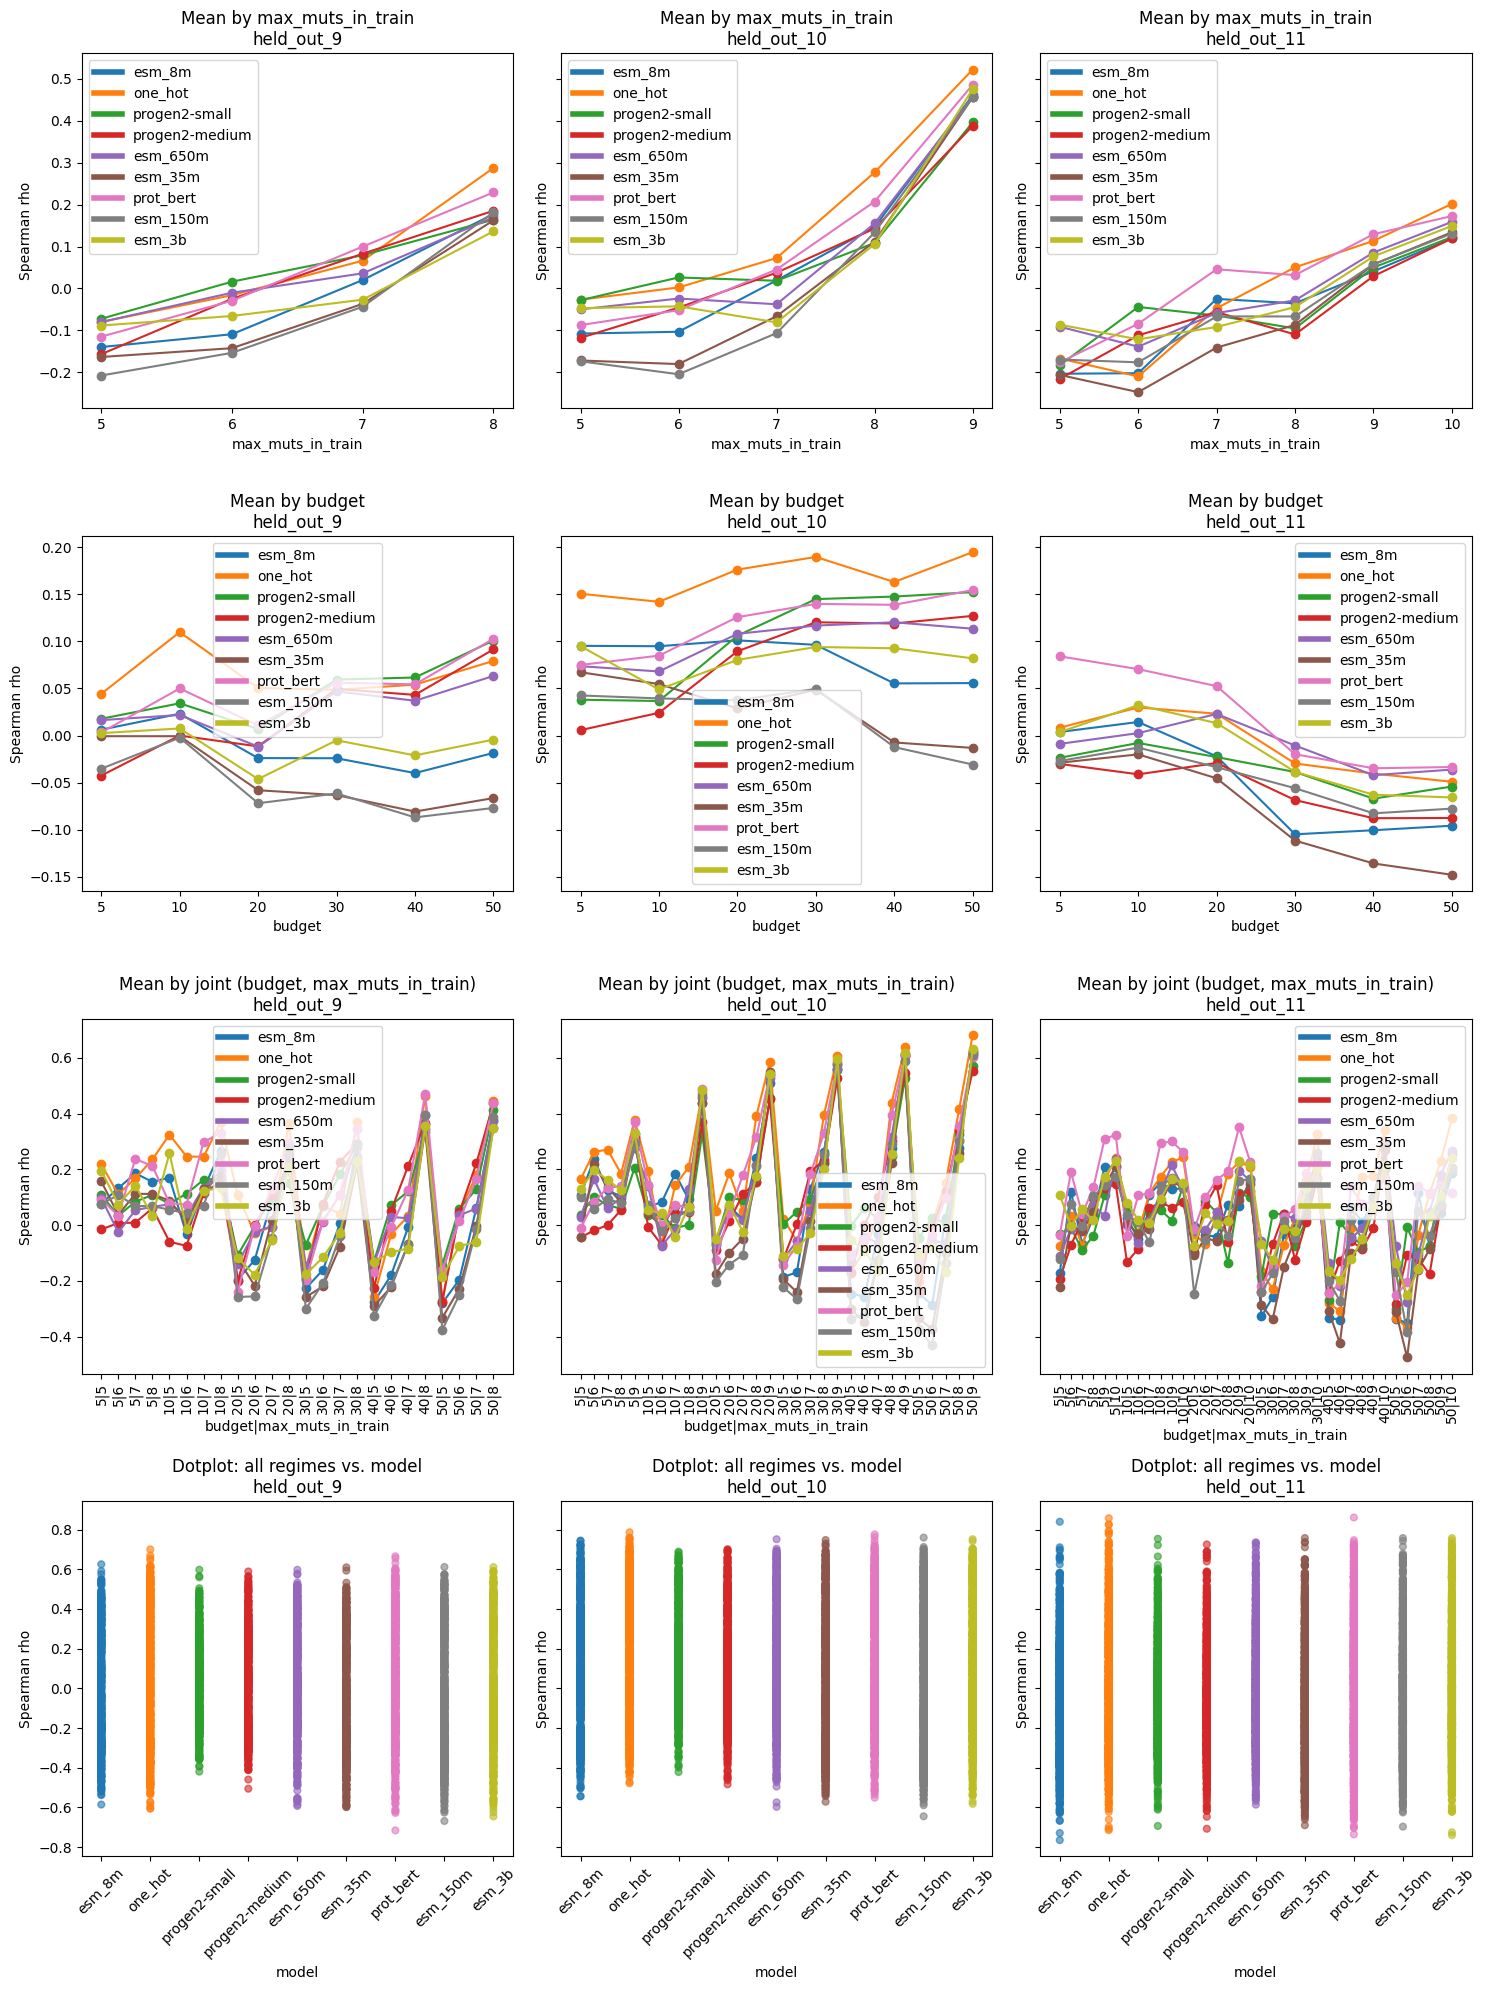

In [6]:
plot_means = True

fig, axes = plt.subplots(4, 3, figsize=(15, 20), sharey="row")
model_names = ["esm_8m", "one_hot", "progen2-small", "progen2-medium", "esm_650m", "esm_35m", "prot_bert", "esm_150m", "esm_3b"]
colors = ["C0", "C1", "C2", "C3", "C4", "C5", "C6", "C7", "C8", "C9"]

for col, (set_name, df_tmp) in enumerate(nmt_sets.items()):
    muts_sorted = sorted(df_tmp["max_muts_in_train"].unique())
    width = 0
    for i, model_name in enumerate(model_names):
        positions = [x + (i - 1) * width for x in range(len(muts_sorted))]
        data = [df_tmp[(df_tmp["max_muts_in_train"] == m) & (df_tmp["model_name"] == model_name)]["cor_llm"] for m in muts_sorted]
        if plot_means:
            means = [d.mean() if len(d) > 0 else np.nan for d in data]
            axes[0, col].plot([p for p in positions], means, marker='o', color=colors[i], label=model_name, linestyle="-")
        else:
            axes[0, col].boxplot(
                data, positions=positions, widths=width*0.9, patch_artist=True, boxprops=dict(facecolor=colors[i]), medianprops=dict(color='black')
            )
    axes[0, col].set_xticks(range(len(muts_sorted)))
    axes[0, col].set_xticklabels(muts_sorted)
    axes[0, col].set_xlabel("max_muts_in_train")
    axes[0, col].set_ylabel("Spearman rho")
    axes[0, col].set_title(f"{'Mean' if plot_means else 'Boxplot'} by max_muts_in_train\n{set_name}")
    axes[0, col].legend([plt.Line2D([0], [0], color=colors[i], lw=4) for i in range(len(model_names))], model_names, loc="best")

    budgets_sorted = sorted(df_tmp["budget"].unique())
    for i, model_name in enumerate(model_names):
        positions = [x + (i - 1) * width for x in range(len(budgets_sorted))]
        data = [df_tmp[(df_tmp["budget"] == b) & (df_tmp["model_name"] == model_name)]["cor_llm"] for b in budgets_sorted]
        if plot_means:
            means = [d.mean() if len(d) > 0 else np.nan for d in data]
            axes[1, col].plot([p for p in positions], means, marker='o', color=colors[i], label=model_name, linestyle="-")
        else:
            axes[1, col].boxplot(
                data, positions=positions, widths=width*0.9, patch_artist=True, boxprops=dict(facecolor=colors[i]), medianprops=dict(color='black')
            )
    axes[1, col].set_xticks(range(len(budgets_sorted)))
    axes[1, col].set_xticklabels(budgets_sorted)
    axes[1, col].set_xlabel("budget")
    axes[1, col].set_ylabel("Spearman rho")
    axes[1, col].set_title(f"{'Mean' if plot_means else 'Boxplot'} by budget\n{set_name}")
    axes[1, col].legend([plt.Line2D([0], [0], color=colors[i], lw=4) for i in range(len(model_names))], model_names, loc="best")

    joint_groups = (
        df_tmp.groupby(["budget", "max_muts_in_train", "model_name"])["cor_llm"]
        .apply(list)
        .reset_index()
    )
    joint_groups["label"] = joint_groups.apply(
        lambda row: f"{int(row['budget'])}|{int(row['max_muts_in_train'])}", axis=1
    )
    base_labels = sorted(
        {(int(row["budget"]), int(row["max_muts_in_train"])) for _, row in joint_groups.iterrows()},
        key=lambda x: (x[0], x[1])
    )
    boxplot_data = {model_name: [] for model_name in model_names}
    boxplot_labels = []
    for budget, max_muts_in_train in base_labels:
        for model_name in model_names:
            rows = joint_groups[
                (joint_groups["budget"] == budget) &
                (joint_groups["max_muts_in_train"] == max_muts_in_train) &
                (joint_groups["model_name"] == model_name)
            ]
            if not rows.empty:
                boxplot_data[model_name].append(rows.iloc[0]["cor_llm"])
            else:
                boxplot_data[model_name].append([])
        boxplot_labels.append(f"{budget}|{max_muts_in_train}")

    for i, model_name in enumerate(model_names):
        positions = [x + (i - 1) * width for x in range(len(boxplot_labels))]
        data = boxplot_data[model_name]
        if plot_means:
            means = [np.percentile(d, 60) if len(d) > 0 else np.nan for d in data]
            axes[2, col].plot([p for p in positions], means, marker='o', color=colors[i], label=model_name, linestyle="-")
        else:
            axes[2, col].boxplot(
                data, positions=positions, widths=width*0.9, patch_artist=True, boxprops=dict(facecolor=colors[i]), medianprops=dict(color='black')
            )
    axes[2, col].set_xticks(range(len(boxplot_labels)))
    axes[2, col].set_xticklabels(boxplot_labels, rotation=90)
    axes[2, col].set_xlabel("budget|max_muts_in_train")
    axes[2, col].set_ylabel("Spearman rho")
    axes[2, col].set_title(f"{'Mean' if plot_means else 'Boxplot'} by joint (budget, max_muts_in_train)\n{set_name}")
    axes[2, col].legend([plt.Line2D([0], [0], color=colors[i], lw=4) for i in range(len(model_names))], model_names, loc="best")

    dotplot_data = []
    dotplot_models = []
    dotplot_colors = []
    for i, model_name in enumerate(model_names):
        vals = df_tmp[df_tmp["model_name"] == model_name]["cor_llm"]
        if hasattr(vals, "explode"):
            vals = vals.explode()
        dotplot_data.extend(vals.astype(float).values.tolist())
        dotplot_models.extend([model_name]*len(vals))
        dotplot_colors.extend([colors[i]]*len(vals))
    xpos = [model_names.index(m) for m in dotplot_models]
    axes[3, col].scatter(xpos, dotplot_data, color=dotplot_colors, alpha=0.6, s=24)
    axes[3, col].set_xticks(range(len(model_names)))
    axes[3, col].set_xticklabels(model_names, rotation=45)
    axes[3, col].set_xlabel("model")
    axes[3, col].set_ylabel("Spearman rho")
    axes[3, col].set_title(f"Dotplot: all regimes vs. model\n{set_name}")

plt.tight_layout()
plt.show()


,set_name,sampling_regime,max_muts_in_train,budget_name,budget,idx,train_sample_indices,num_muts,cor_llm,model_name


In [7]:
joint_groups

,budget,max_muts_in_train,model_name,cor_llm


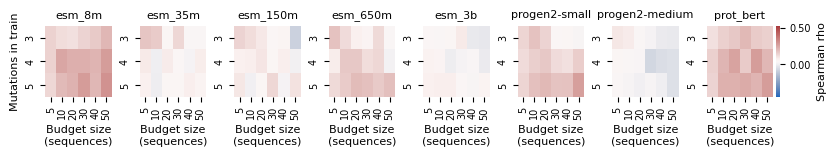

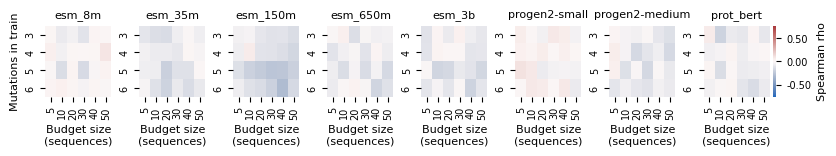

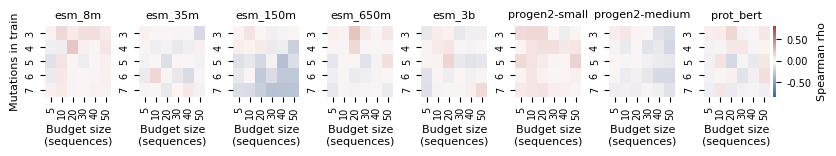

In [4]:


title_fontsize = 8
label_fontsize = 8
tick_fontsize = 7
legend_fontsize = 7

model_names = ["esm_8m", "esm_35m", "esm_150m", "esm_650m",  "esm_3b",  "progen2-small", "progen2-medium", "prot_bert"]



all_tensors = []
one_hot_tensors = []

for set_name, df_tmp in gcn_sets.items():
    held_out_tensor = []
    muts_sorted = sorted(df_tmp["max_muts_in_train"].unique())
    budgets_sorted = sorted(df_tmp["budget"].unique())

    all_spearman_values = []
    for model_name in model_names:
        for b in budgets_sorted:
            for m in muts_sorted:
                vals = df_tmp[
                    (df_tmp["budget"] == b)
                    & (df_tmp["max_muts_in_train"] == m)
                    & (df_tmp["model_name"] == model_name)
                ]["cor_llm"]
                if hasattr(vals, "explode"):
                    vals = vals.explode()
                all_spearman_values.extend(vals.astype(float).values.tolist())
    vmin = np.nanmin(all_spearman_values)
    vmax = np.nanmax(all_spearman_values)

    fig, axes = plt.subplots(1, 8, figsize=(8.25, 1.45), constrained_layout=True)

    for ax, model_name in zip(axes, model_names):
        heatmap_vals = np.full((len(muts_sorted), len(budgets_sorted)), np.nan)
        for i, m in enumerate(muts_sorted):
            for j, b in enumerate(budgets_sorted):
                vals = df_tmp[
                    (df_tmp["budget"] == b)
                    & (df_tmp["max_muts_in_train"] == m)
                    & (df_tmp["model_name"] == model_name)
                ]["cor_llm"]
                if len(vals) > 0:
                    try:
                        numeric_vals = vals.astype(float).values
                        value = np.median(numeric_vals)
                    except Exception:
                        value = np.nan
                else:
                    value = np.nan
                heatmap_vals[i, j] = value

        if model_name == "one_hot":
            one_hot_tensors.append(heatmap_vals)
        else:
            held_out_tensor.append(heatmap_vals)

        # Create the heatmap and keep the return value (which is the Axes object)
        cbar_show = (ax == axes[-1])
        heatmap = sns.heatmap(
            heatmap_vals,
            annot=False,
            fmt=".2f",
            xticklabels=budgets_sorted,
            yticklabels=muts_sorted,
            ax=ax,
            vmin=vmin,
            vmax=vmax,
            cmap="vlag",
            cbar=cbar_show,  # Only show colorbar on last plot
            cbar_kws={"label": "Spearman rho", "shrink": 1.0, "format": "%.2f"} if cbar_show else None,
        )
        # Set colorbar label and tick font size (only for the colorbar instance)
        if cbar_show and heatmap.collections:
            cbar = heatmap.collections[0].colorbar
            cbar.set_label("Spearman rho", fontsize=label_fontsize)
            cbar.ax.tick_params(labelsize=tick_fontsize)
        ax.set_title(model_name, fontsize=title_fontsize)
        ax.set_xlabel("Budget size\n(sequences)", fontsize=label_fontsize)
        ax.set_ylabel("Mutations in train" if ax == axes[0] else "", fontsize=label_fontsize)
        ax.tick_params(axis="x", labelsize=tick_fontsize)
        ax.tick_params(axis="y", labelsize=tick_fontsize)

    held_out_tensor = np.stack(held_out_tensor, axis=0)
    all_tensors.append(held_out_tensor)

    #fig.suptitle(f"Spearman rho heatmap for '{set_name}'", fontsize=title_fontsize)
    plt.show()
    output_dir = "./figures/figure_2"
    os.makedirs(output_dir, exist_ok=True)
    fig.savefig(os.path.join(output_dir, "nmt_heatmap_%s.svg" % set_name), bbox_inches='tight')



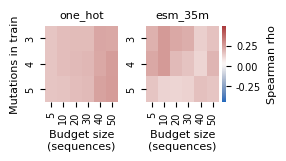

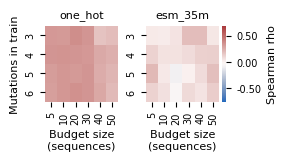

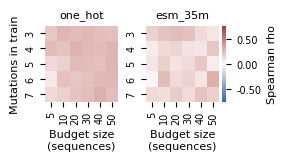

In [13]:
title_fontsize = 8
label_fontsize = 8
tick_fontsize = 7
legend_fontsize = 7

model_names = ["one_hot", "esm_35m"]

set_infos = [
    (df_9, "held_out_9"),
    (df_10, "held_out_10"),
    (df_11, "held_out_11"),
]

all_tensors = []
one_hot_tensors = []

for df_tmp, set_name in set_infos:
    held_out_tensor = []
    muts_sorted = sorted(df_tmp["max_muts_in_train"].unique())
    budgets_sorted = sorted(df_tmp["budget"].unique())

    all_spearman_values = []
    for model_name in model_names:
        for b in budgets_sorted:
            for m in muts_sorted:
                vals = df_tmp[
                    (df_tmp["budget"] == b)
                    & (df_tmp["max_muts_in_train"] == m)
                    & (df_tmp["model_name"] == model_name)
                ]["cor_llm"]
                if hasattr(vals, "explode"):
                    vals = vals.explode()
                all_spearman_values.extend(vals.astype(float).values.tolist())
    vmin = np.nanmin(all_spearman_values)
    vmax = np.nanmax(all_spearman_values)

    fig, axes = plt.subplots(1, 2, figsize=(2.75, 1.5), constrained_layout=True)

    for ax, model_name in zip(axes, model_names):
        heatmap_vals = np.full((len(muts_sorted), len(budgets_sorted)), np.nan)
        for i, m in enumerate(muts_sorted):
            for j, b in enumerate(budgets_sorted):
                vals = df_tmp[
                    (df_tmp["budget"] == b)
                    & (df_tmp["max_muts_in_train"] == m)
                    & (df_tmp["model_name"] == model_name)
                ]["cor_llm"]
                if len(vals) > 0:
                    try:
                        numeric_vals = vals.astype(float).values
                        value = np.percentile(numeric_vals, 75)
                    except Exception:
                        value = np.nan
                else:
                    value = np.nan
                heatmap_vals[i, j] = value

        if model_name == "one_hot":
            one_hot_tensors.append(heatmap_vals)
        else:
            held_out_tensor.append(heatmap_vals)

        # Create the heatmap and keep the return value (which is the Axes object)
        cbar_show = (ax == axes[-1])
        heatmap = sns.heatmap(
            heatmap_vals,
            annot=False,
            fmt=".2f",
            xticklabels=budgets_sorted,
            yticklabels=muts_sorted,
            ax=ax,
            vmin=vmin,
            vmax=vmax,
            cmap="vlag",
            cbar=cbar_show,  # Only show colorbar on last plot
            cbar_kws={"label": "Spearman rho", "shrink": 1.0, "format": "%.2f"} if cbar_show else None,
        )
        # Set colorbar label and tick font size (only for the colorbar instance)
        if cbar_show and heatmap.collections:
            cbar = heatmap.collections[0].colorbar
            cbar.set_label("Spearman rho", fontsize=label_fontsize)
            cbar.ax.tick_params(labelsize=tick_fontsize)
        ax.set_title(model_name, fontsize=title_fontsize)
        ax.set_xlabel("Budget size\n(sequences)", fontsize=label_fontsize)
        ax.set_ylabel("Mutations in train" if ax == axes[0] else "", fontsize=label_fontsize)
        ax.tick_params(axis="x", labelsize=tick_fontsize)
        ax.tick_params(axis="y", labelsize=tick_fontsize)

    held_out_tensor = np.stack(held_out_tensor, axis=0)
    all_tensors.append(held_out_tensor)

    #fig.suptitle(f"Spearman rho heatmap for '{set_name}'", fontsize=title_fontsize)
    plt.show()
    output_dir = "./figures/figure_3"
    os.makedirs(output_dir, exist_ok=True)
    fig.savefig(os.path.join(output_dir, "nmt_heatmap_ohe_llm%s.svg" % set_name), bbox_inches='tight')



In [17]:
df_tmp["model_name"].unique()

array(['esm_8m', 'esm_35m', 'esm_150m', 'esm_650m', 'esm_3b', 'one_hot',
       'progen2-small', 'progen2-medium', 'prot_bert'], dtype=object)

In [15]:
def mean_without_nan(statistics_matrix):
    mu_vec = np.apply_along_axis(lambda col: np.nanmean(col), axis=0, arr=statistics_matrix)
    return mu_vec

def calculate_ss_for_df_and_factors(df, 
    factors = ["model_name", "train_mutations"], 
    variables_to_calculate = ["roc", "top_100_pct", "precision", "f1", "accuracy", "recall"]
):
    results = []
    ss_all = []

    for var in variables_to_calculate:
        SS_ALL = (df[var] - df[var].mean()) ** 2
        for factor in factors:
            groups_in_factor = df[factor].unique()
            for group in groups_in_factor:
                group_df = df[df[factor] == group]
                SS = (group_df[var] - group_df[var].mean()) ** 2
                results.append({
                    'factor_name': factor,
                    'SS': SS.sum(),
                    'group': group,
                    'var': var
                })

        ss_all.append({"var": var, "SS": SS_ALL.sum()})

    results_df = pd.DataFrame(results)
    ss_all = pd.DataFrame(ss_all)

    return ss_all, results_df





In [20]:
# no_ohe_df = df[df["model_name"] != "one_hot"]
# held_out_sets = no_ohe_df["set_name"].unique()
# models = no_ohe_df["model_name"].unique()

factors = ["model_name", "budget", "max_muts_in_train"]

vars_and_func = {"mean_cor_llm" : lambda v: vals.mean(),
                #  "std_cor_llm" : lambda v: vals.std(),
                # "median_cor_llm" : lambda v: vals.median(),
                #  "min_cor_llm" : lambda v: vals.min(),
                #  "max_cor_llm" : lambda v: vals.max(),
                 "med" : lambda v: np.percentile(vals, 50)}#,
                #  "25_cor_llm" : lambda v: np.percentile(vals, 25),
                #"85_cor_llm" : lambda v: np.percentile(vals, 85),
                #  "15_cor_llm" : lambda v: np.percentile(vals, 15),
                #"95_cor_llm" : lambda v: np.percentile(vals, 95),
                #"05_cor_llm" : lambda v: np.percentile(vals, 5)}


discretized_parameter_scale = {"esm_35m": "0_100",
                                "esm_8m": "0_100",
                                "esm_150m": "100_500",
                                "esm_650m": "500_1000",
                                "esm_3b": "500_1000",
                                "progen2-small": "100_500",
                                "progen2-medium": "500_1000",
                                "prot_bert": "100_500"}


vars = list(vars_and_func.keys())
results = []

for held_out_set, df_tmp in gcn_sets.items():
    

    models = df_tmp["model_name"].unique()
    models = models[models != "one_hot"]
    
    #df_tmp = df[df["set_name"] == held_out_set]
    muts_sorted = sorted(df_tmp["max_muts_in_train"].unique())
    budgets_sorted = sorted(df_tmp["budget"].unique())

    for model_name in models:
        df_tmp_model = df_tmp[df_tmp["model_name"] == model_name]
        
        for b in budgets_sorted:
            for m in muts_sorted:
                vals = df_tmp_model[(df_tmp_model["budget"] == b) & (
                                     df_tmp_model["max_muts_in_train"] == m)]["cor_llm"]
                                     
                metadata = {"model_name": model_name, 
                            "budget": b, 
                            "max_muts_in_train": m, 
                            #"muts_budget": f"m_{m}_b_{b}",
                            #"muts_model": f"m_{m}_mdl_{model_name}",
                            #"budget_model": f"b_{b}_mdl_{model_name}",
                            "set": held_out_set,
                            "scale": discretized_parameter_scale[model_name]}

                statistics = {var: vars_and_func[var](vals) for var in vars}
                results.append({**metadata, **statistics})


                    



In [21]:
rsdf =  pd.DataFrame(results)

var_explained_factor_results = []

extended_factors = np.concatenate([factors, ["scale"]])#, "muts_budget", "muts_model", "budget_model"]])
for held_out_set in gcn_sets.keys():

    ss_all, results_df = calculate_ss_for_df_and_factors(rsdf[rsdf["set"] == held_out_set], 
                                                         factors=extended_factors, 
                                                         variables_to_calculate=vars)

    for var in vars:
        for factor in extended_factors:
            ss_factor_for_var = results_df[(results_df["factor_name"] == factor) & (results_df["var"] == var)]["SS"].sum()
            total_ss_in_var = ss_all[ss_all["var"] == var]["SS"]
                

            var_explained_factor_results.append({"var": var, 
                                                "factor": factor, 
                                                "var_explained": (1 - ss_factor_for_var / total_ss_in_var).item()})

var_explained_factor_df = pd.DataFrame(var_explained_factor_results)

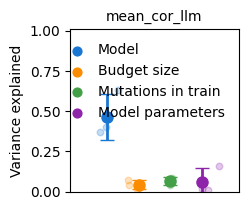

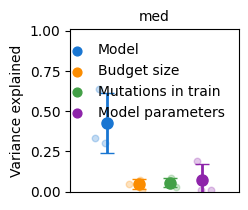

In [24]:
# --- Dotplot for variance explained by each factor (side-by-side, per var) ---
factor_order = ['model_name', 'budget', 'max_muts_in_train', 'scale']

color_palette = ["#1976D2", "#FB8C00", "#43A047", "#8E24AA"]
factor_colors = {f: color_palette[i % len(color_palette)] for i, f in enumerate(factor_order)}

for var in var_explained_factor_df['var'].unique():
    plot_df = var_explained_factor_df[var_explained_factor_df['var'] == var]
    # Prepare means and stds per factor in order
    means = []
    stds = []
    for f in factor_order:
        vals = plot_df[plot_df['factor'] == f]['var_explained']
        means.append(vals.mean())
        stds.append(vals.std())
    means = np.array(means)
    stds = np.array(stds)

    fig, ax = plt.subplots(figsize=(2.5, 2.2))
    # Arrange factors horizontally, slightly spread
    x_center = 0.55
    sep = 0.08
    factor_xs = {f: x_center + sep*(i - (len(factor_order)-1)/2) for i, f in enumerate(factor_order)}
    # Scatter individual points per factor
    for i, f in enumerate(factor_order):
        yvals = plot_df[plot_df['factor'] == f]['var_explained'].values
        if len(yvals) > 0:
            xvals = np.random.normal(loc=factor_xs[f], scale=sep/4, size=len(yvals))
            ax.scatter(xvals, yvals, color=factor_colors[f], alpha=0.25, s=22, zorder=1)
    # Means + error bars per factor
    for i, (f, mean, std) in enumerate(zip(factor_order, means, stds)):
        ax.errorbar(factor_xs[f], mean, yerr=std, fmt='o',
                    color=factor_colors[f], elinewidth=2, capsize=5, markersize=8, zorder=2)
    # Remove x-axis ticks/labels, show only legend with factor names mapped to color
    ax.set_xlim(x_center - sep*len(factor_order)/1.5, x_center + sep*len(factor_order)/1.5)
    ax.set_xticks([])
    for i, f in enumerate(factor_order):
        ax.scatter([], [], color=factor_colors[f], label=xlabel_dict.get(f, f), s=40)
    ax.legend(fontsize=legend_fontsize, frameon=False, loc="best", handletextpad=0.5, borderpad=0.5)
    ax.set_ylabel("Variance explained", fontsize=label_fontsize)
    ax.set_title(ylabel_dict.get(var, var), fontsize=title_fontsize)
    ax.tick_params(axis='y', labelsize=tick_fontsize)
    ax.set_ylim(0, 1.01)
    plt.tight_layout()
    plt.show()
    plt.close()

/tmp/ipykernel_2203710/282526533.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xlabels, rotation=30, ha='right', fontsize=tick_fontsize)


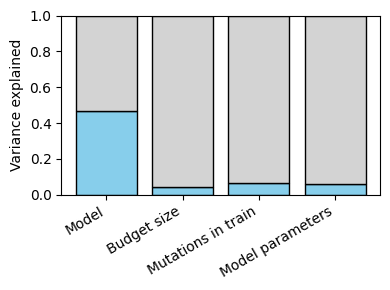

/tmp/ipykernel_2203710/282526533.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xlabels, rotation=30, ha='right', fontsize=tick_fontsize)


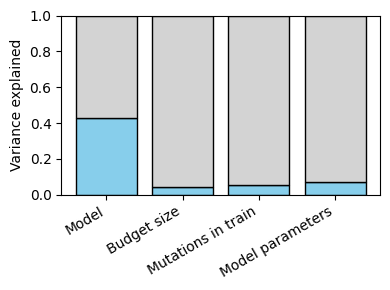

In [22]:
xlabel_dict = {
    'model_name': 'Model',
    'scale': 'Model parameters',
    'max_muts_in_train': 'Mutations in train',
    'budget': 'Budget size'
}

title_fontsize = 10
label_fontsize = 10
tick_fontsize = 10
legend_fontsize = 10

for var in var_explained_factor_df['var'].unique():
    plot_df = var_explained_factor_df[var_explained_factor_df['var'] == var]
    factors = plot_df['factor'].unique()
    means = []
    for f in extended_factors:
        vals = plot_df[plot_df['factor'] == f]['var_explained']
        means.append(vals.mean())

    means = np.array(means)
    leftover = 1.0 - means
    leftover = np.clip(leftover, 0, 1)  # ensure no negative bar

    x = np.arange(len(extended_factors))
    fig, ax = plt.subplots(figsize=(4, 3))

    # The main (colored) bar
    bar1 = ax.bar(x, means, color="skyblue", edgecolor="k", label='Explained')
    # The leftover (gray) bar, stacked above
    bar2 = ax.bar(x, leftover, bottom=means, color="lightgray", edgecolor="k", label='Unexplained')

    xlabels = [xlabel_dict[f] for f in extended_factors]
    ax.set_xticklabels(xlabels, rotation=30, ha='right', fontsize=tick_fontsize)
    ax.set_ylabel('Variance explained', fontsize=label_fontsize)
    ax.set_xticks(x)
    ax.set_ylim(0, 1)

    # Optionally, legend:
    # ax.legend(fontsize=legend_fontsize)

    plt.tight_layout()
    output_dir = "./figures/figure_2"
    os.makedirs(output_dir, exist_ok=True)
    #plt.savefig(os.path.join(output_dir, "var_explained_nmt_%s.svg" % var), bbox_inches='tight')
    plt.show()
    plt.close()


In [30]:
a = "S101,D103,P106,M107,F108,E109,Y110,E111,N112,L113,E114,D115,N116,S117,K118,E119,T121,S122,D125,N126,D127,I128,P129,V130,T131,T132,D133,D134,V135,S136,L137,A138,D139,K140,A141,I142,E143,S144,"
gcn = pd.read_csv("data/gcn4/gcn4.csv")


In [ ]:
a = [len(pd.unique(gcn["S101"]))

14